In [1]:
%load_ext autoreload
%autoreload 2
cmd = "S"
import sys
parent_dir = "C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal"

import json
import pandas as pd
import os
import pickle
sys.path.append(parent_dir)
holidays_path = "C:/Users/yuhang.hou/projects/holidays"
sys.path.append(holidays_path)
from backtester import *
from utils import *

last_trading_days = get_last_trading_days(cmd)
ltds = {k:pd.to_datetime(v) for k,v in last_trading_days.items()}

business_days = load_business_days_cmd(cmd)
business_days = sorted(business_days)

def process_results(results):
    res =[]
    for date, data in results.items():
        temp= { }
        temp['date'] = date
        temp['level'] = data['level']
        temp['tc'] = data['tc']
        res.append(temp)
    res = pd.DataFrame(res)
    res = res.set_index('date')
    res['tc_cumsum'] = res['tc'].cumsum()
    return res

def load_future_data(data_path = f'./data/{cmd}',values = 'close'):
    files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
    dfs = (pd.read_csv(os.path.join(data_path, file)).assign(
        contract=file.replace('.csv', ''),
        date=lambda df: pd.to_datetime(df['date'])
    ) for file in files)

    big_df = pd.concat(dfs, ignore_index=True)
    pivot_df = big_df.pivot(index='date', columns='contract', values= values)

    return pivot_df

contract_df = load_future_data(f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/future/cme/{cmd}',['close'])
contract_df = contract_df.ffill()
# contract_df.head()
contract_df.dropna(how='all', inplace=True)
start_date = '2013-07-01'
end_date = '2026-01-01'

In [2]:
contract_df.tail(5)

close                                                              \
contract      F01    F02    F03    F04     F05     F06    F07     F08     F09   
date                                                                            
2026-02-04  499.5  421.0  569.5  789.0  547.75  597.75  683.5  1199.0  972.25   
2026-02-05  499.5  421.0  569.5  789.0  547.75  597.75  683.5  1199.0  972.25   
2026-02-06  499.5  421.0  569.5  789.0  547.75  597.75  683.5  1199.0  972.25   
2026-02-09  499.5  421.0  569.5  789.0  547.75  597.75  683.5  1199.0  972.25   
2026-02-10  499.5  421.0  569.5  789.0  547.75  597.75  683.5  1199.0  972.25   

                     ...                                                   \
contract        F10  ...     X20      X21     X22     X23    X24      X25   
date                 ...                                                    
2026-02-04  1039.75  ...  1056.5  1235.75  1407.0  1287.0  982.5  1099.75   
2026-02-05  1039.75  ...  1056.5  1235.75  1407.0  1287.0  982.5  1099.75   
2026-02-06  1039.75  ...  1056.5  1235.75  1407.0  1287.0  982.5  1099.75   
2026-02-09  1039.75  ...  1056.5  1235.75  1407.0  1287.0  982.5  1099.75   
2026-02-10  1039.75  ...  1056.5  1235.75  1407.0  1287.0  982.5  1099.75   

                                                
contract        X26      X27      X28      X29  
date                                            
2026-02-04  1087.50  1084.25  1082.00  1089.50  
2026-02-05  1098.50  1087.75  1084.75  1092.25  
2026-02-06  1094.00  1080.50  1078.75  1086.25  
2026-02-09  1095.75  1082.50  1079.75  1087.25  
2026-02-10  1106.50  1090.50  1087.75  1095.25  

[5 rows x 204 columns]

In [3]:
# skip_dates = set(
#     [
#         pd.to_datetime('2001-01-15'),
#         pd.to_datetime('2001-02-19'),
#         pd.to_datetime('2004-12-31'),
#         pd.to_datetime('2005-11-24'),
#         pd.to_datetime('2009-11-26'),
#         pd.to_datetime('2025-01-01'),
#         pd.to_datetime('2025-09-20'),
#         pd.to_datetime('2025-09-21'),

#     ]
# )
# data =   vol_series = pd.read_csv('C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/S/S_0_3.csv')
# data['date'] = pd.to_datetime(data['date'])
# data = data[data['close'].isna()]
# print(len(data))
# skip_dates = skip_dates.union(set(data['date']))

# business_days = sorted(list(set(business_days)-skip_dates) )


In [ ]:
roll_schedules = [
    'HKKNNXXXXF*F*H*',
    # 'KKNNXXXXF*F*H*H*',
    # 'XXXXXXXXX*X*X*X*',
    # 'KNNXXXXF*F*H*H*K*',
#     'NNXXXXF*F*H*H*K*K*',
#     'NXXXXF*F*H*H*K*K*N*',
    # 'XXXXF*F*H*H*K*K*N*N*',
#     'XXXF*F*H*H*K*K*N*N*X*',
#     'XXF*F*H*H*K*K*N*N*X*X*',
    # 'XF*F*H*H*K*K*N*N*X*X*X*',
#     'F*F*H*H*K*K*N*N*X*X*X*X*',
]


In [5]:
final_df = pd.DataFrame()

####  Signals are:
1. STU 
2. STU Z Score
3. STU diff zscore

In [6]:
import numpy as np
for signal_type in [ 'z_all_diff']:#[ 'STU_DIFF_SIG','STU_SIG', 'STU_diff']:
    for signal_delay in [0]:
        for i,roll_schedule in enumerate(roll_schedules):
            config = {
                'start_date': start_date,
                'end_date': end_date,
                'roll_start': -10,
                'roll_schedule':roll_schedule,
                'roll_dates': 1,
                'max_position': 1,
                'longshort': 1,
                'roll_style': 'monthly',  
                'cost_type':'percentage',
                'slippage': 0.0,
                'commission': 0,
                'roll_out' : 1,
                'vol_target': 5000,
                'round': 0,
                'max_daily_volume': 1,
                'lookback':10,
                'signal_low': -0.09,
                'signal_high': 0.09,
                'signal_delay': signal_delay,
                'signal_col': signal_type, # 'STU', 'STU_DIFF_SIG','STU_SIG', 'STU_diff'
                'vol_series':'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/S/S_0_3.csv',
                'signal_path':f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal/signals.csv'

            }

            backtest = SignalBacktester(
                data = contract_df,
                config = config,
                trading_days=business_days,
                last_trading_day=ltds
            )
                
            results = backtest.run_backtest()
            res = process_results(results)
            final_df[f'{cmd}'] = res['level']  




<Axes: xlabel='date'>

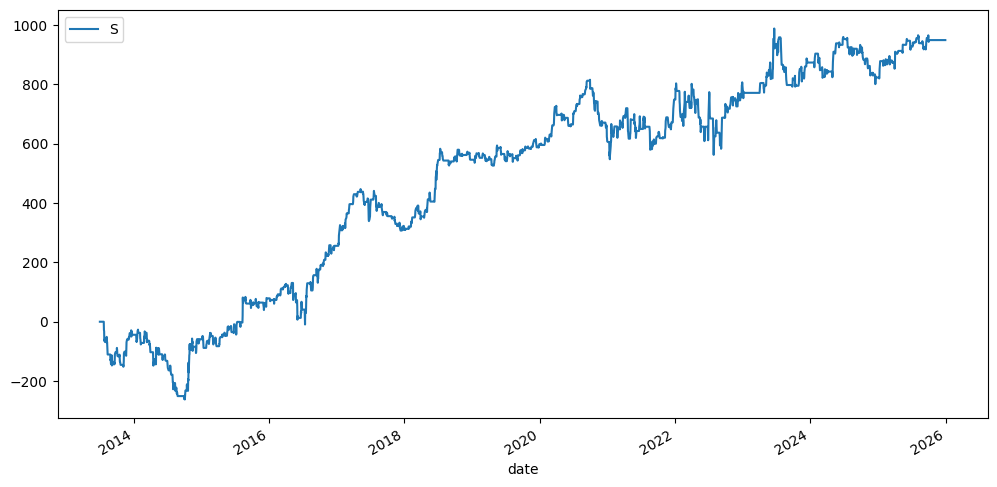

In [7]:
final_df.plot(figsize=(12,6))